In [131]:
#!pip -q install pypdf nltk matplotlib pandas


In [132]:
# Bibliotecas essenciais

import re 
from collections import Counter
from nltk.corpus import stopwords

import pandas as pd
import matplotlib.pyplot as plt

import nltk
nltk.download("punkt")
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /home/davi-
[nltk_data]     maciel/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/davi-
[nltk_data]     maciel/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/davi-
[nltk_data]     maciel/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [133]:
# Leitura dos livros em PDF

from pypdf import PdfReader

pdf_cortico = "o-cortico.pdf"
pdf_expresso_baturite = "misterio-no-expresso-baturite.pdf"


def carregar_texto_pdf(caminho_pdf):
    reader = PdfReader(caminho_pdf)
    paginas = []
    for page in reader.pages:
        conteudo = page.extract_text() or ""
        paginas.append(conteudo)
    return "\n".join(paginas)


conteudo_bruto_cortico = carregar_texto_pdf(pdf_cortico)
conteudo_bruto_expresso = carregar_texto_pdf(pdf_expresso_baturite)

len(conteudo_bruto_cortico), len(conteudo_bruto_expresso)

(472595, 106350)

In [134]:
# Padronização textual básica
# Corrige hifenizações e quebras antes de qualquer estatística.


def higienizar_texto(texto_original):
    texto = re.sub(r"-\s*\n\s*", "", texto_original)
    texto = re.sub(r"\s*\n\s*", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


def remover_bloco_por_faixa(texto, inicio, fim):
    texto_normalizado = texto.casefold()
    inicio_norm = inicio.casefold()
    fim_norm = fim.casefold()
    ini = texto_normalizado.find(inicio_norm)
    if ini == -1:
        return texto
    fim_idx = texto_normalizado.find(fim_norm, ini + len(inicio_norm))
    if fim_idx == -1:
        return texto
    return texto[:ini] + texto[fim_idx + len(fim):]


def remover_secoes_editoriais(texto):
    blocos = [
        ("Milson Almeida\nIlustrações Mings", "(Todos os Direitos Reservados)"),
        ("Milson Almeida\nOlá, sou Milson Almeida", "neste voo sem limites!"),
        ("Mings\nMeu nome é José Domingues", "sociedade mais humana e justa"),
        ("O Cortiço, de Aluísio de Azevedo", "mantidas."),
    ]
    filtrado = texto
    for inicio, fim in blocos:
        filtrado = remover_bloco_por_faixa(filtrado, inicio, fim)
    return re.sub(r"\s+", " ", filtrado).strip()


texto_cortico_limpo = higienizar_texto(remover_secoes_editoriais(conteudo_bruto_cortico))
texto_expresso_limpo = higienizar_texto(remover_secoes_editoriais(conteudo_bruto_expresso))

len(texto_cortico_limpo), len(texto_expresso_limpo)

(466180, 103086)

In [135]:
# Tokenização das sentenças e expressões de uso corrente

TOKEN_REGEX = re.compile(r"[A-Za-zÀ-ÖØ-öø-ÿ']+")

def tokens_sentenca(sentenca: str):
    return TOKEN_REGEX.findall(sentenca.lower())

def medir_sentencas(texto):
    sentencas = nltk.sent_tokenize(texto, language="portuguese")
    comprimentos = [len(tokens_sentenca(s)) for s in sentencas if s.strip()]
    return sentencas, [c for c in comprimentos if c > 0]


lista_sentencas_cortico, comprimentos_cortico = medir_sentencas(texto_cortico_limpo)
lista_sentencas_expresso, comprimentos_expresso = medir_sentencas(texto_expresso_limpo)

frases_cotidianas = [
    "bom dia, tudo bem?",
    "quanto custa isso?",
    "eu acho que sim",
    "não tenho certeza",
    "me desculpe, não entendi",
    "me manda por favor",
    "obrigado, de verdade",
    "a gente se fala depois",
    "não faz sentido",
    "pode repetir?",
]

comprimentos_frases = [len(tokens_sentenca(frase)) for frase in frases_cotidianas]

media_sentencas_cortico = sum(comprimentos_cortico) / len(comprimentos_cortico)
media_sentencas_expresso = sum(comprimentos_expresso) / len(comprimentos_expresso)
media_frases_cotidianas = sum(comprimentos_frases) / len(comprimentos_frases)

print("Sentenças analisadas em O Cortiço:", len(lista_sentencas_cortico))
print("Sentenças analisadas em Expresso Baturité:", len(lista_sentencas_expresso))
print("Média de palavras por sentença (O Cortiço):", round(media_sentencas_cortico, 2))
print("Média de palavras por sentença (Expresso Baturité):", round(media_sentencas_expresso, 2))
print("Média de palavras por expressão cotidiana:", round(media_frases_cotidianas, 2))

Sentenças analisadas em O Cortiço: 5108
Sentenças analisadas em Expresso Baturité: 1243
Média de palavras por sentença (O Cortiço): 16.26
Média de palavras por sentença (Expresso Baturité): 14.64
Média de palavras por expressão cotidiana: 3.5


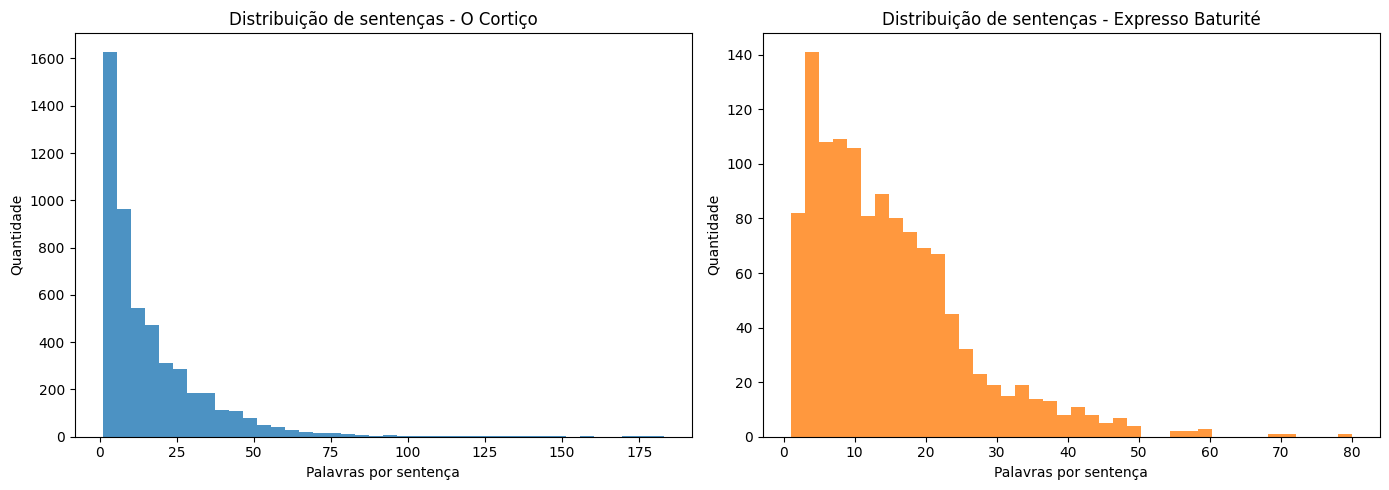

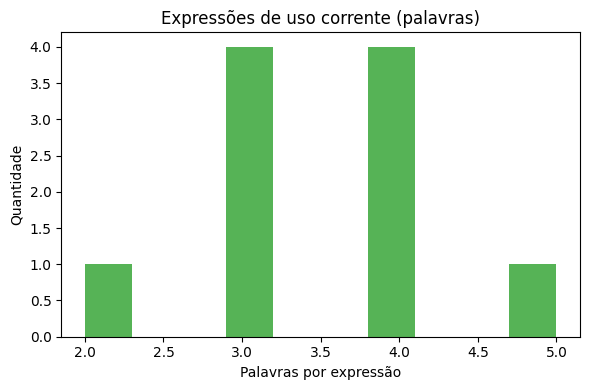

In [136]:
# Histogramas: distribuição do tamanho das sentenças

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.hist(comprimentos_cortico, bins=40, color="#1f77b4", alpha=0.8)
plt.title("Distribuição de sentenças - O Cortiço")
plt.xlabel("Palavras por sentença")
plt.ylabel("Quantidade")

plt.subplot(1, 2, 2)
plt.hist(comprimentos_expresso, bins=40, color="#ff7f0e", alpha=0.8)
plt.title("Distribuição de sentenças - Expresso Baturité")
plt.xlabel("Palavras por sentença")
plt.ylabel("Quantidade")

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(comprimentos_frases, bins=10, color="#2ca02c", alpha=0.8)
plt.title("Expressões de uso corrente (palavras)")
plt.xlabel("Palavras por expressão")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

In [137]:
# Métricas de variedade lexical para cada obra

def calcular_metricas_lexicais(texto):
    tokens = TOKEN_REGEX.findall(texto.lower())
    total_tokens = len(tokens)
    contagem = Counter(tokens)
    vocab = len(contagem)
    hapax = sum(1 for _, freq in contagem.items() if freq == 1)
    ttr = vocab / total_tokens if total_tokens else 0
    hapax_ratio = hapax / vocab if vocab else 0
    return {
        "total_tokens": total_tokens,
        "vocab": vocab,
        "hapax": hapax,
        "ttr": round(ttr, 4),
        "hapax_ratio": round(hapax_ratio, 4),
    }, contagem


metricas_cortico_dict, contagem_cortico_tokens = calcular_metricas_lexicais(texto_cortico_limpo)
metricas_expresso_dict, contagem_expresso_tokens = calcular_metricas_lexicais(texto_expresso_limpo)

print("Resumo lexical - O Cortiço:")
for chave, valor in metricas_cortico_dict.items():
    print(f"  {chave}: {valor}")

print("\nResumo lexical - Expresso Baturité:")
for chave, valor in metricas_expresso_dict.items():
    print(f"  {chave}: {valor}")

Resumo lexical - O Cortiço:
  total_tokens: 83060
  vocab: 12056
  hapax: 6816
  ttr: 0.1451
  hapax_ratio: 0.5654

Resumo lexical - Expresso Baturité:
  total_tokens: 18152
  vocab: 3790
  hapax: 2268
  ttr: 0.2088
  hapax_ratio: 0.5984


In [138]:
# Comparação direta entre os dois livros

quadro_comparativo = pd.DataFrame(
    [
        {"obra": "O Cortiço", **metricas_cortico_dict},
        {"obra": "Expresso Baturité", **metricas_expresso_dict},
    ]
)
quadro_comparativo

,obra,total_tokens,vocab,hapax,ttr,hapax_ratio
0,O Cortiço,83060,12056,6816,0.1451,0.5654
1,Expresso Baturité,18152,3790,2268,0.2088,0.5984


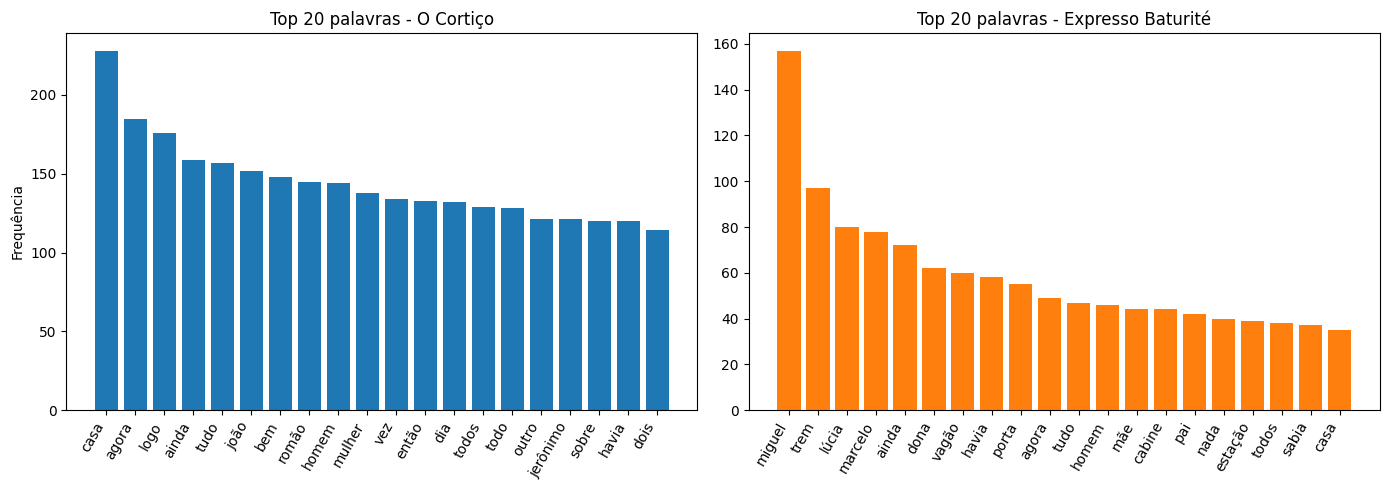

(  Palavra  Frequência
 0    casa         228
 1   agora         185
 2    logo         176
 3   ainda         159
 4    tudo         157
 5    joão         152
 6     bem         148
 7   romão         145
 8   homem         144
 9  mulher         138,
    Palavra  Frequência
 0   miguel         157
 1     trem          97
 2    lúcia          80
 3  marcelo          78
 4    ainda          72
 5     dona          62
 6    vagão          60
 7    havia          58
 8    porta          55
 9    agora          49)

In [139]:
# Palavras mais frequentes (sem stopwords) em cada livro

stopwords_pt = set(stopwords.words("portuguese"))

def contar_sem_stopwords(texto):
    tokens_filtrados = [
        token
        for token in TOKEN_REGEX.findall(texto.lower())
        if len(token) > 2 and token not in stopwords_pt
    ]
    return Counter(tokens_filtrados)


frequencias_sem_stop_cortico = contar_sem_stopwords(texto_cortico_limpo)
frequencias_sem_stop_expresso = contar_sem_stopwords(texto_expresso_limpo)

qtde_top = 20
top_cortico_df = pd.DataFrame(frequencias_sem_stop_cortico.most_common(qtde_top), columns=["Palavra", "Frequência"])
top_expresso_df = pd.DataFrame(frequencias_sem_stop_expresso.most_common(qtde_top), columns=["Palavra", "Frequência"])

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.bar(top_cortico_df["Palavra"], top_cortico_df["Frequência"], color="#1f77b4")
plt.title(f"Top {qtde_top} palavras - O Cortiço")
plt.xticks(rotation=60, ha="right")
plt.ylabel("Frequência")

plt.subplot(1, 2, 2)
plt.bar(top_expresso_df["Palavra"], top_expresso_df["Frequência"], color="#ff7f0e")
plt.title(f"Top {qtde_top} palavras - Expresso Baturité")
plt.xticks(rotation=60, ha="right")

plt.tight_layout()
plt.show()

top_cortico_df.head(10), top_expresso_df.head(10)

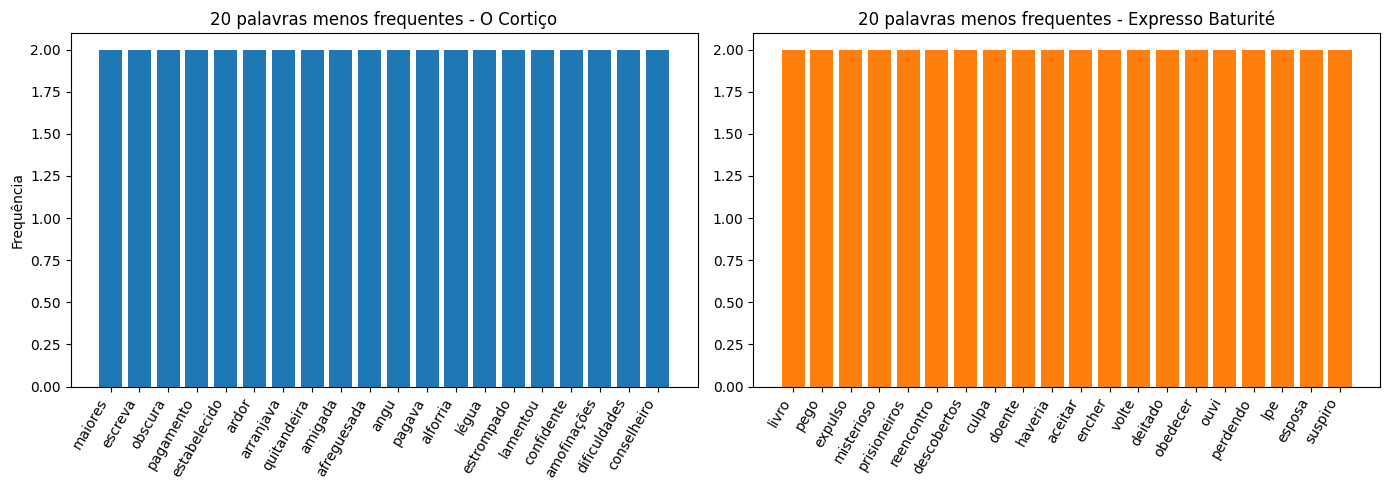

(        Palavra  Frequência
 0       maiores           2
 1       escreva           2
 2       obscura           2
 3     pagamento           2
 4  estabelecido           2,
         Palavra  Frequência
 0         livro           2
 1          pego           2
 2       expulso           2
 3    misterioso           2
 4  prisioneiros           2)

In [140]:
# Palavras menos frequentes (filtrando rodapés e hapax irrelevantes)

rodapes_ignorados = [
    "http", "www", "com", "br", "org", "net", "usp", "bibvirt", "seduc",
    "copyright", "revisão", "coordenação", "ilustrações", "editorial", "projeto",
    "milson", "silva", "mings", "saudosamente", "respon", "ago", "m", "p", "lta", "ez"
]
frequencia_minima = 2

def selecionar_palavras_raras(contagem):
    raras = [
        (palavra, freq)
        for palavra, freq in contagem.items()
        if freq >= frequencia_minima and palavra not in rodapes_ignorados
    ]
    return sorted(raras, key=lambda x: x[1])[:20]


raras_cortico_df = pd.DataFrame(selecionar_palavras_raras(contagem_cortico_tokens), columns=["Palavra", "Frequência"])
raras_expresso_df = pd.DataFrame(selecionar_palavras_raras(contagem_expresso_tokens), columns=["Palavra", "Frequência"])

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.bar(raras_cortico_df["Palavra"], raras_cortico_df["Frequência"], color="#1f77b4")
plt.title("20 palavras menos frequentes - O Cortiço")
plt.xticks(rotation=60, ha="right")
plt.ylabel("Frequência")

plt.subplot(1, 2, 2)
plt.bar(raras_expresso_df["Palavra"], raras_expresso_df["Frequência"], color="#ff7f0e")
plt.title("20 palavras menos frequentes - Expresso Baturité")
plt.xticks(rotation=60, ha="right")

plt.tight_layout()
plt.show()

raras_cortico_df.head(), raras_expresso_df.head()

In [141]:
# Resumo final para TC.4

relatorio = f"""
Resumo quantitativo das obras:
- O Cortiço: {metricas_cortico_dict['total_tokens']} tokens, {metricas_cortico_dict['vocab']} palavras distintas,
  TTR = {metricas_cortico_dict['ttr']}, Hapax = {metricas_cortico_dict['hapax']} (ratio {metricas_cortico_dict['hapax_ratio']})
- Expresso Baturité: {metricas_expresso_dict['total_tokens']} tokens, {metricas_expresso_dict['vocab']} palavras distintas,
  TTR = {metricas_expresso_dict['ttr']}, Hapax = {metricas_expresso_dict['hapax']} (ratio {metricas_expresso_dict['hapax_ratio']})

Estrutura frasal:
- Sentenças analisadas O Cortiço: {len(comprimentos_cortico)}, média de {media_sentencas_cortico:.2f} palavras
- Sentenças analisadas Expresso Baturité: {len(comprimentos_expresso)}, média de {media_sentencas_expresso:.2f} palavras
- Expressões de uso corrente: média de {media_frases_cotidianas:.2f} palavras
"""

print(relatorio)


Resumo quantitativo das obras:
- O Cortiço: 83060 tokens, 12056 palavras distintas,
  TTR = 0.1451, Hapax = 6816 (ratio 0.5654)
- Expresso Baturité: 18152 tokens, 3790 palavras distintas,
  TTR = 0.2088, Hapax = 2268 (ratio 0.5984)

Estrutura frasal:
- Sentenças analisadas O Cortiço: 5107, média de 16.26 palavras
- Sentenças analisadas Expresso Baturité: 1240, média de 14.64 palavras
- Expressões de uso corrente: média de 3.50 palavras



Interpretação:
- O Cortiço apresenta frases longas e vocabulário amplo, concentrando palavras formais e descrições sociais.
- Expresso Baturité, mesmo sendo narrativo, mostra frases ligeiramente mais curtas e vocabulário menos repetitivo,
  refletindo o ritmo de um texto de mistério.